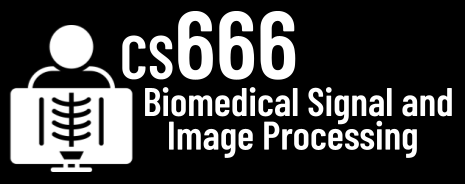
#Assignment 4

In [15]:
# NAME: Leo Navarro Mercado

In [16]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [17]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['axes', 'f']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [18]:
# we are using mahotas again, so lets install it!
!pip install mahotas

In [19]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [20]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!
!wget https://www.dropbox.com/s/2ca2889o2ql8n4e/xray.zip?dl=1 -O xray.zip

--2026-04-22 03:11:35--  https://www.dropbox.com/s/2ca2889o2ql8n4e/xray.zip?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1 [following]
--2026-04-22 03:11:35--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucd61ce1e0630050f355560ccf31.dl.dropboxusercontent.com/cd/0/inline/C_CkdP_ZeBdV__frDHBUsLd__rB9V9dkY8qw5sZ2hhOjcceIflNpZwUkRZsruxKeab8jouS8zovxmvwxcShKDDoBe8753-CUctNlkn7ZbT78eOMtkN_l5I8q-Qsk4hjli8M/file?dl=1# [following]
--2026-04-22 03:11:36--  https://ucd61ce1e0630050f355560ccf31.dl.dropboxusercontent.com/cd/0/inline/C_CkdP_ZeBdV__

In [21]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [22]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [23]:
# TODO: Please display this image and print the dimensions!

(1858, 2090)


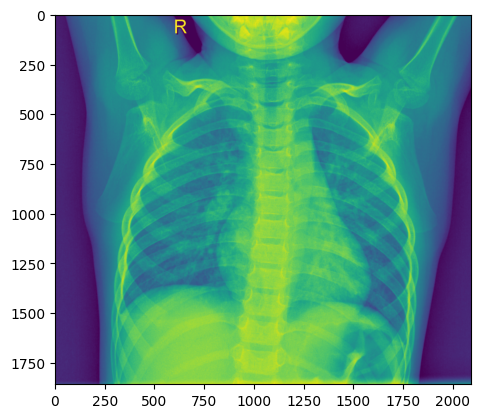

In [24]:
import matplotlib.pyplot as plt

print(img.shape)
plt.imshow(img)

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [25]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [26]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) Grayscale conversion
# TODO: Operation 2) Image resize
# TODO: Operation 3) Storing images in a pre-allocated array

In [27]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

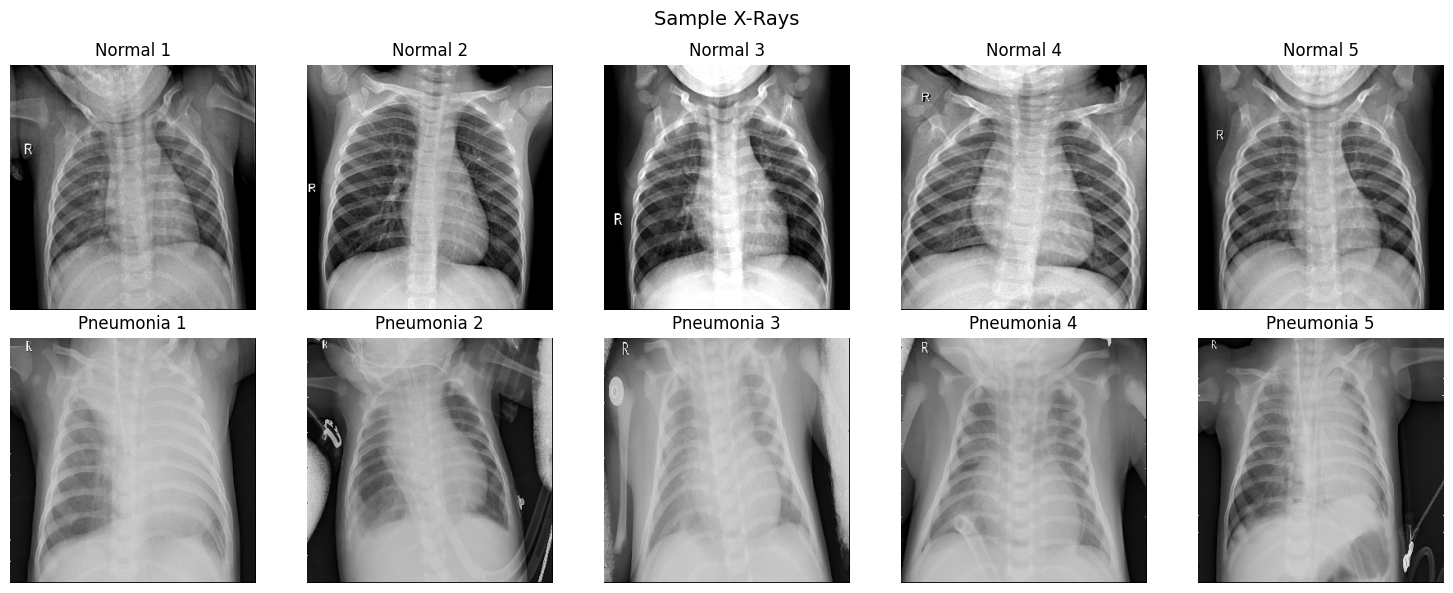

In [46]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    axes[0, i].imshow(data[0][i], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Normal {i+1}')

for i in range(5):
    axes[1, i].imshow(data[1][i], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Pneumonia {i+1}')


plt.suptitle('Sample X-Rays', fontsize=14)
plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [29]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [30]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [33]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.array([0] * TRAINING_COUNT + [1] * TRAINING_COUNT + [2] * TRAINING_COUNT)

In [34]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [35]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.array([0] * TESTING_COUNT + [1] * TESTING_COUNT + [2] * TESTING_COUNT)

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [36]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [37]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [38]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [ ]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [ ]:
'''
Random forest is a ML algorithm that uses decision trees in order to make better predicitions
Where each tree looks at different random parts of data and the results in order improve accuracy.
'''

In [40]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.9166666666666666

In [ ]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [ ]:
'''This is pretty good accuracy and does surprise me to see that it's above 90%'''

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [47]:
print(clf.n_estimators)

100


In [52]:
# Now, please use a single tree and observe the testing performance.

In [50]:
clf1 = RandomForestClassifier(n_estimators=1)
fitted = clf1.fit( X_train, y_train )
clf1.score( X_test, y_test )

0.75

In [51]:
# Are you surprised?

In [ ]:
'''Im surprised it still got 3 quarters of the answers correct'''

**Bonus:** Let's take a closer look! [33 Points]

In [53]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [58]:
UNSEEN_COUNT = 99

X_unseen = np.zeros((UNSEEN_COUNT, 300*300), dtype=np.float32)
t_pos = 0

for image in data[2][100:199]:
    image = image.ravel()
    image /= image.max()
    X_unseen[t_pos] = image
    t_pos += 1

y_unseen = np.array([2] * UNSEEN_COUNT)

y_pred = clf.predict(X_unseen)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_unseen, y_pred))

0.9797979797979798


In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

In [ ]:
# TODO: YOUR CODE AND YOUR ANSWER

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw